In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Data Loading
Load the LendingClub dataset from Google Drive. We start with 10,000 rows for exploration, then scale to 50,000 for modeling.

In [2]:

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/accepted_2007_to_2018Q4.csv.gz', compression='gzip', nrows=10000, low_memory=False)
print(df.shape)
df.head()

(10000, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Total columns:", df.shape[1])
print(df.columns.tolist())

Total columns: 151
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint'

In [4]:
print(df['loan_status'].value_counts())

loan_status
Fully Paid            7189
Charged Off           1713
Current               1024
Late (31-120 days)      58
In Grace Period         12
Late (16-30 days)        4
Name: count, dtype: int64


# 2. Data Cleaning & Target Creation
Filter only loans with clear outcomes: Fully Paid (0) and Charged Off (1). Create binary target variable.

In [5]:
df_clean = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

df_clean['target'] = df_clean['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)

print(df_clean.shape)
print(df_clean['target'].value_counts())

(8902, 152)
target
0    7189
1    1713
Name: count, dtype: int64


In [6]:
features = ['loan_amnt', 'term', 'int_rate', 'installment', 'grade',
            'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
            'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high',
            'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc']

df_model = df_clean[features + ['target']].copy()
print(df_model.shape)
df_model.isnull().sum()

(8902, 20)


,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
emp_length,505
home_ownership,0
annual_inc,0
verification_status,0
purpose,0


In [7]:

df_model['emp_length'] = df_model['emp_length'].fillna(df_model['emp_length'].mode()[0])
df_model['revol_util'] = df_model['revol_util'].fillna(df_model['revol_util'].median())
df_model['dti'] = df_model['dti'].fillna(df_model['dti'].median())
df_model['delinq_2yrs'] = df_model['delinq_2yrs'].fillna(0)
df_model['pub_rec'] = df_model['pub_rec'].fillna(0)
print(df_model.isnull().sum().sum())  # should be 0

0


# 3. Exploratory Data Analysis (EDA)
Visualize distributions, correlations, and default rates across loan grades and purposes.

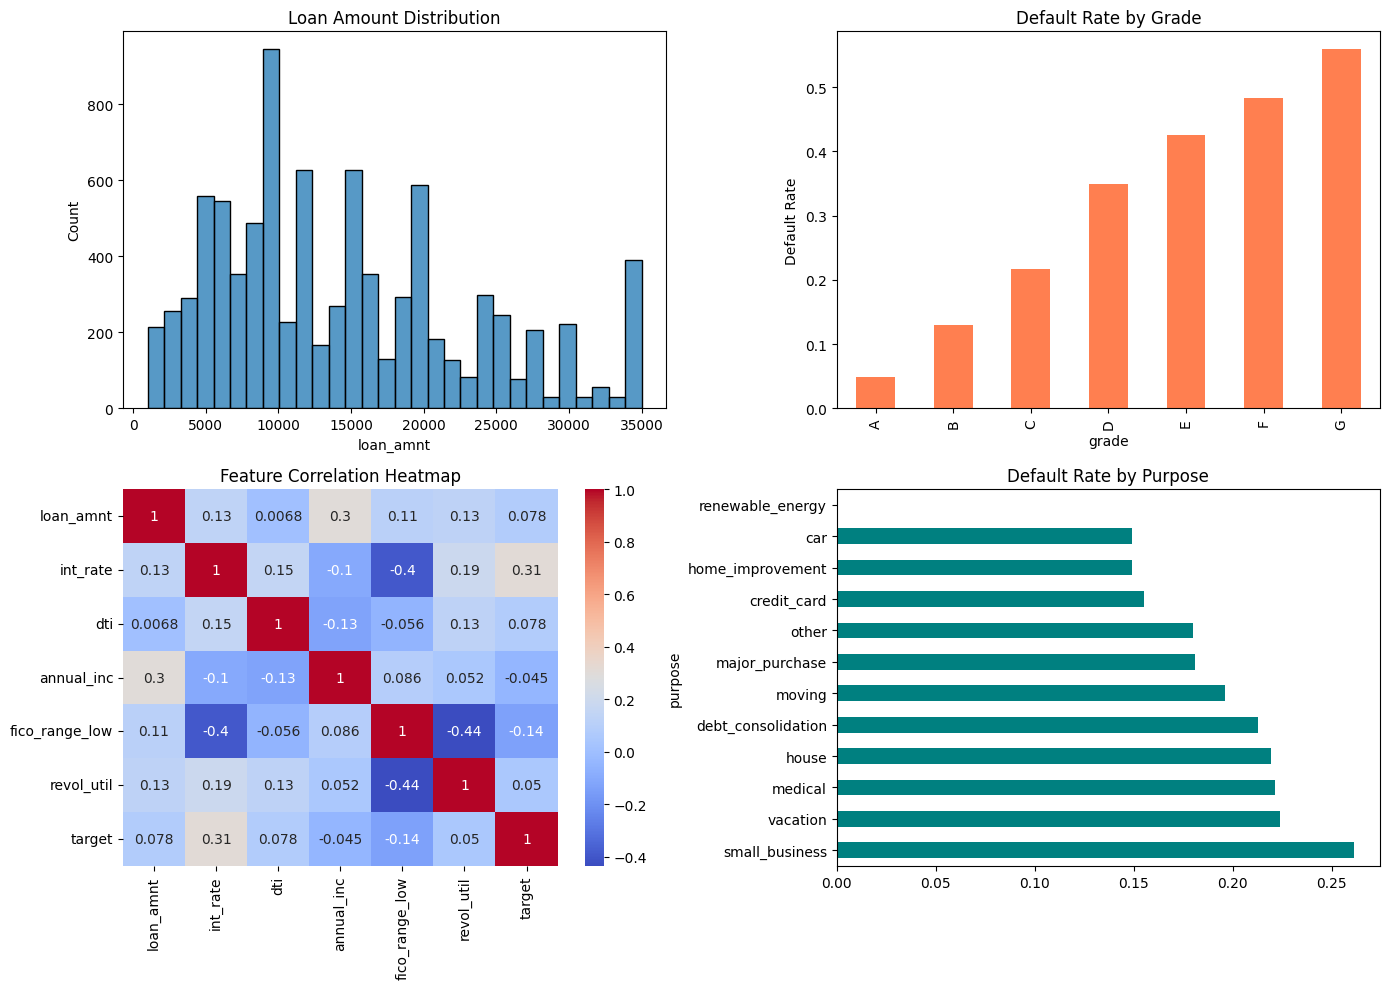

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loan amount distribution
sns.histplot(df_model['loan_amnt'], bins=30, ax=axes[0,0])
axes[0,0].set_title('Loan Amount Distribution')

# 2. Default rate by grade
grade_default = df_clean.groupby('grade')['target'].mean().sort_index()
grade_default.plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Default Rate by Grade')
axes[0,1].set_ylabel('Default Rate')

# 3. Correlation heatmap (top features)
top_features = ['loan_amnt', 'int_rate', 'dti', 'annual_inc', 'fico_range_low', 'revol_util', 'target']
sns.heatmap(df_model[top_features].corr(), annot=True, cmap='coolwarm', ax=axes[1,0])
axes[1,0].set_title('Feature Correlation Heatmap')

# 4. Default rate by purpose
purpose_default = df_clean.groupby('purpose')['target'].mean().sort_values(ascending=False)
purpose_default.plot(kind='barh', ax=axes[1,1], color='teal')
axes[1,1].set_title('Default Rate by Purpose')

plt.tight_layout()
plt.show()

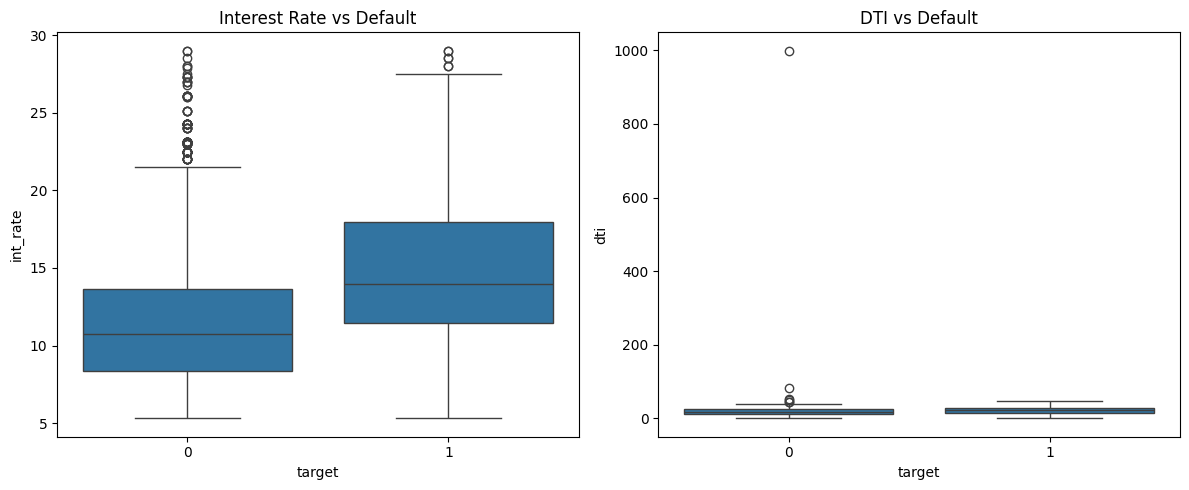

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='target', y='int_rate', data=df_model, ax=axes[0])
axes[0].set_title('Interest Rate vs Default')

sns.boxplot(x='target', y='dti', data=df_model, ax=axes[1])
axes[1].set_title('DTI vs Default')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['term', 'grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose']

for col in categorical_cols:
    df_model[col] = df_model[col].astype('category').cat.codes

df_model.head()

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc,target
0,3600.0,0,13.99,123.03,2,1,0,55000.0,0,2,5.91,0.0,675.0,679.0,7.0,0.0,2765.0,29.7,13.0,0
1,24700.0,0,11.99,820.28,2,1,0,65000.0,0,10,16.06,1.0,715.0,719.0,22.0,0.0,21470.0,19.2,38.0,0
2,20000.0,1,10.78,432.66,1,1,0,63000.0,0,3,10.78,0.0,695.0,699.0,6.0,0.0,7869.0,56.2,18.0,0
4,10400.0,1,22.45,289.91,5,3,0,104433.0,1,5,25.37,1.0,695.0,699.0,12.0,0.0,21929.0,64.5,35.0,0
5,11950.0,0,13.44,405.18,2,4,2,34000.0,1,2,10.20,0.0,690.0,694.0,5.0,0.0,8822.0,68.4,6.0,0


In [11]:
from sklearn.model_selection import train_test_split

X = df_model.drop('target', axis=1)
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (7121, 19)
Test size: (1781, 19)


In [12]:
# Remove outliers using ONLY training data thresholds
dti_cap = X_train['dti'].quantile(0.995)
inc_cap = X_train['annual_inc'].quantile(0.995)

train_mask = (X_train['dti'] < dti_cap) & (X_train['annual_inc'] < inc_cap)
X_train = X_train[train_mask]
y_train = y_train[train_mask]

test_mask = (X_test['dti'] < dti_cap) & (X_test['annual_inc'] < inc_cap)
X_test = X_test[test_mask]
y_test = y_test[test_mask]

print("Train size after outlier removal:", X_train.shape)
print("Test size after outlier removal:", X_test.shape)

Train size after outlier removal: (7047, 19)
Test size after outlier removal: (1769, 19)


# 4. Baseline Model: Logistic Regression
Train a simple baseline with feature scaling. Logistic Regression assumes linear relationships, so it serves as a good benchmark.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale features (Logistic Regression works better with scaled data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [14]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_pred = log_model.predict(X_test_scaled)
y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8066704352741662
AUC-ROC: 0.726153624500885

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.96      0.89      1429
           1       0.49      0.16      0.24       340

    accuracy                           0.81      1769
   macro avg       0.66      0.56      0.56      1769
weighted avg       0.76      0.81      0.76      1769



# 5. XGBoost with Class Imbalance Handling
XGBoost handles non-linear relationships better. We first try `scale_pos_weight`, then compare with SMOTE inside cross-validation.

In [15]:
from xgboost import XGBClassifier

# Handle class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully")

XGBoost trained successfully


In [16]:
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

Accuracy: 0.7524024872809497
AUC-ROC: 0.6575597908862636

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.85      1429
           1       0.36      0.37      0.36       340

    accuracy                           0.75      1769
   macro avg       0.60      0.61      0.60      1769
weighted avg       0.75      0.75      0.75      1769



int_rate               0.130619
term                   0.118741
home_ownership         0.062396
pub_rec                0.052193
installment            0.050232
revol_util             0.048564
loan_amnt              0.048507
annual_inc             0.048416
revol_bal              0.047632
delinq_2yrs            0.046831
purpose                0.045950
dti                    0.045626
fico_range_low         0.045517
total_acc              0.043247
open_acc               0.042216
verification_status    0.041578
grade                  0.041353
emp_length             0.040384
fico_range_high        0.000000
dtype: float32


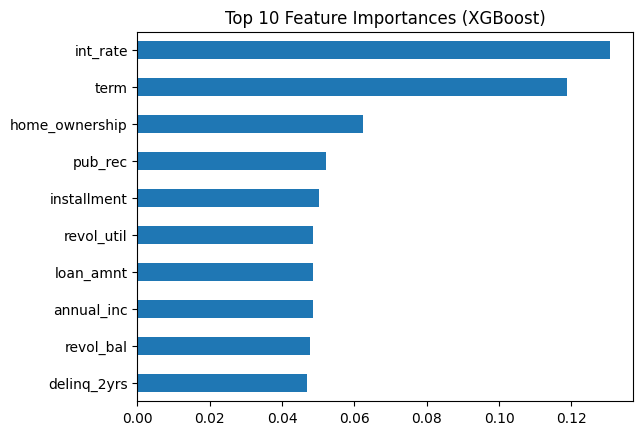

In [17]:
import pandas as pd

importance = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance)

importance.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.gca().invert_yaxis()
plt.show()

In [19]:
# Reload with more data
df = pd.read_csv('/content/drive/MyDrive/accepted_2007_to_2018Q4.csv.gz', compression='gzip', nrows=50000, low_memory=False)

# Repeat cleaning pipeline
df_clean = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df_clean['target'] = df_clean['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)

features = ['loan_amnt', 'term', 'int_rate', 'installment', 'grade',
            'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
            'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high',
            'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc']

df_model = df_clean[features + ['target']].copy()

# Handle missing values
df_model['emp_length'] = df_model['emp_length'].fillna(df_model['emp_length'].mode()[0])
df_model['revol_util'] = df_model['revol_util'].fillna(df_model['revol_util'].median())

# Encode categorical
categorical_cols = ['term', 'grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose']
for col in categorical_cols:
    df_model[col] = df_model[col].astype('category').cat.codes

print(df_model.shape)
print(df_model['target'].value_counts())

(43921, 20)
target
0    34901
1     9020
Name: count, dtype: int64


# 6. SMOTE + GridSearchCV with Proper Pipeline
**Key fix:** SMOTE is applied inside each CV fold using `imblearn.pipeline`, preventing data leakage. This gives an honest estimate of model performance on imbalanced test data.

In [20]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X = df_model.drop('target', axis=1)
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Remove outliers using training thresholds
dti_cap = X_train['dti'].quantile(0.995)
inc_cap = X_train['annual_inc'].quantile(0.995)
train_mask = (X_train['dti'] < dti_cap) & (X_train['annual_inc'] < inc_cap)
X_train = X_train[train_mask]
y_train = y_train[train_mask]
test_mask = (X_test['dti'] < dti_cap) & (X_test['annual_inc'] < inc_cap)
X_test = X_test[test_mask]
y_test = y_test[test_mask]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train default rate:", y_train.mean().round(3))

Train size: (34745, 19)
Test size: (8683, 19)
Train default rate: 0.205


In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Baseline XGBoost on imbalanced data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_base = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
xgb_base.fit(X_train, y_train)

y_pred_base = xgb_base.predict(X_test)
y_pred_proba_base = xgb_base.predict_proba(X_test)[:, 1]

print("Baseline XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba_base))
print(classification_report(y_test, y_pred_base))

Baseline XGBoost
Accuracy: 0.7028676724634343
AUC-ROC: 0.7047863153858032
              precision    recall  f1-score   support

           0       0.87      0.74      0.80      6902
           1       0.36      0.56      0.44      1781

    accuracy                           0.70      8683
   macro avg       0.61      0.65      0.62      8683
weighted avg       0.76      0.70      0.72      8683



In [22]:
from sklearn.model_selection import GridSearchCV

# Pipeline: SMOTE happens INSIDE each CV fold
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(random_state=42, eval_metric='logloss'))
])

param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5],
    'xgb__learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(pipeline, param_grid, scoring='roc_auc', cv=3)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

Best params: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 5, 'xgb__n_estimators': 200}
Best CV AUC: 0.7148920255720329


In [23]:
best_model = grid.best_estimator_

y_pred3 = best_model.predict(X_test)
y_pred_proba3 = best_model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred3))
print("Test AUC-ROC:", roc_auc_score(y_test, y_pred_proba3))
print("\nClassification Report:\n", classification_report(y_test, y_pred3))

Test Accuracy: 0.7905101923298399
Test AUC-ROC: 0.7227528545542788

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.93      0.88      6902
           1       0.48      0.24      0.32      1781

    accuracy                           0.79      8683
   macro avg       0.65      0.59      0.60      8683
weighted avg       0.76      0.79      0.76      8683



# 7. Final Evaluation & Sample Predictions
Evaluate the tuned model on the held-out test set and show predictions on sample applicants.

In [24]:
# Show predictions on sample test data
sample = X_test.head(10).copy()
sample['Actual'] = y_test.head(10).values
sample['Predicted'] = best_model.predict(X_test.head(10))
sample['Default_Probability'] = best_model.predict_proba(X_test.head(10))[:, 1].round(3)

sample[['loan_amnt', 'int_rate', 'grade', 'Actual', 'Predicted', 'Default_Probability']]

,loan_amnt,int_rate,grade,Actual,Predicted,Default_Probability
29692,13000.0,11.99,2,0,0,0.222
38682,8000.0,14.48,2,0,0,0.367
7947,21000.0,10.64,1,0,0,0.234
47369,14000.0,13.18,2,0,0,0.348
38000,10000.0,7.26,0,0,0,0.121
32450,9600.0,11.22,1,0,0,0.135
14665,31350.0,14.48,2,1,1,0.541
37380,12000.0,7.89,0,0,0,0.131
44165,10000.0,15.41,3,1,0,0.372
22705,14000.0,11.99,2,0,0,0.189
